In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/

In [2]:
model = tf.keras.models.load_model("aqi_model_v2.keras")  
# or use your final model name if different

In [3]:
img_path = "test/Test Image.jpg"   # adjust path if needed

img = image.load_img(img_path, target_size=(100, 100))
img_array = image.img_to_array(img)

# Keep a copy BEFORE normalization (important)
original_img = img_array.copy()

# Normalize for model
img_array = np.expand_dims(img_array, axis=0) / 255.0

In [4]:
class_names = ["Good", "Moderate", "Severe", "Unhealthy"]

In [5]:
def create_variations(img):

    variations = {}

    # Brightness increase
    variations["bright"] = np.clip(img + 50, 0, 255)

    # Dark image
    variations["dark"] = np.clip(img - 50, 0, 255)

    # Low contrast
    variations["low_contrast"] = np.clip(img * 0.5, 0, 255)

    # High contrast
    variations["high_contrast"] = np.clip(img * 1.5, 0, 255)

    return variations

In [6]:
variations = create_variations(original_img)

In [7]:
original_pred = model.predict(img_array)
original_class = np.argmax(original_pred)

print("Original Prediction:", class_names[original_class])
print("Confidence:", original_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Original Prediction: Unhealthy
Confidence: [[0.00917718 0.2962936  0.14013857 0.55439067]]


In [8]:
results = {}

for name, var_img in variations.items():

    # Normalize same as training
    var_img = np.expand_dims(var_img, axis=0) / 255.0

    pred = model.predict(var_img)
    pred_class = np.argmax(pred)

    results[name] = (class_names[pred_class], pred)

    print(f"{name.upper()} → {class_names[pred_class]} | {pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
BRIGHT → Unhealthy | [[0.01018337 0.29763103 0.1422305  0.5499552 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
DARK → Unhealthy | [[0.00876749 0.29548323 0.13966902 0.5560802 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
LOW_CONTRAST → Unhealthy | [[0.00845754 0.29431352 0.14042264 0.55680627]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
HIGH_CONTRAST → Unhealthy | [[0.01061616 0.2986212  0.14208078 0.5486818 ]]


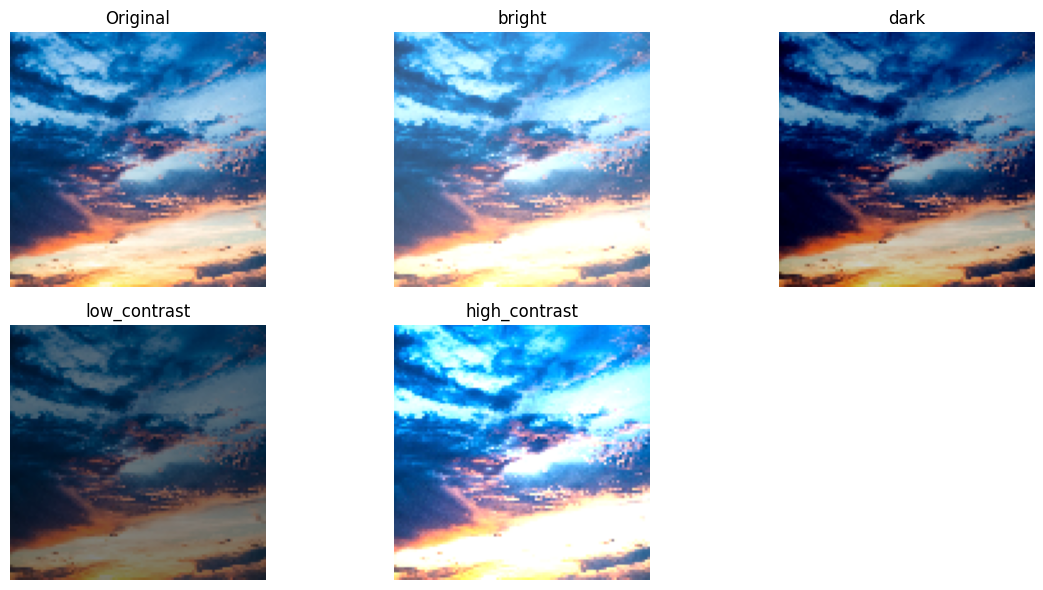

In [9]:
plt.figure(figsize=(12, 6))

# Show original
plt.subplot(2, 3, 1)
plt.imshow(original_img.astype("uint8"))
plt.title("Original")
plt.axis("off")

# Show variations
i = 2
for name, var_img in variations.items():
    plt.subplot(2, 3, i)
    plt.imshow(var_img.astype("uint8"))
    plt.title(name)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

In [10]:
print("\n=== FINAL ANALYSIS ===")

print("Original:", class_names[np.argmax(original_pred)])

for name, (label, pred) in results.items():
    print(f"{name}: {label}")


=== FINAL ANALYSIS ===
Original: Unhealthy
bright: Unhealthy
dark: Unhealthy
low_contrast: Unhealthy
high_contrast: Unhealthy
